## Credit Score Models Base Training ##

### Global Imports ###

In [1]:
import os
import joblib
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

### EDA (Exploratory Data Analysis) ###
It is a critical process used to analyze, summarise and visualize data sets. It helps uncover patterns, spot anomalies, check assumptions, and handle missing values before building statistical or machine learning models

In [2]:
####Loading Training Data####

credit_score_dataframe = pd.read_csv("credit_score_train_data.csv", low_memory=False)
print("Dataset shape:", credit_score_dataframe.shape)
display(credit_score_dataframe.head())

print("\nColumn names:")
print(credit_score_dataframe.columns.tolist())

print("\nData types:")
credit_score_dataframe.info()

print("\nMissing values:")
print(credit_score_dataframe.isnull().sum())


Dataset shape: (100000, 28)


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good



Column names:
['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Payment_of_Min_Amount', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance', 'Credit_Score']

Data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age         

In [3]:
### Data Requirement Check ####

print("Number of rows:", credit_score_dataframe.shape[0])
print("Number of columns:", credit_score_dataframe.shape[1])

if credit_score_dataframe.shape[0] >= 500:
    print("✓ Minimum instance requirement satisfied")
else:
    print("✗ Dataset contains fewer than 500 rows")

if credit_score_dataframe.shape[1] - 1 >= 12:
    print("✓ Minimum feature requirement satisfied")
else:
    print("✗ Dataset contains fewer than 12 features")

Number of rows: 100000
Number of columns: 28
✓ Minimum instance requirement satisfied
✓ Minimum feature requirement satisfied


In [4]:
#### Data Cleaning ####

def data_clean_numeric(series):
    return pd.to_numeric(
        series.astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("_", "", regex=False)
        .str.strip(),
        errors="coerce"
    )

for col in credit_score_dataframe.columns:
    if credit_score_dataframe[col].dtype == 'object':
        converted = data_clean_numeric(credit_score_dataframe[col])
        
        if converted.notna().sum() > 0.7 * len(credit_score_dataframe):
            credit_score_dataframe[col] = converted

display(credit_score_dataframe.tail())

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
99995,0x25fe9,CUS_0x942c,April,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,...,_,502.38,34.663572,31 Years and 6 Months,No,35.104023,60.971333,High_spent_Large_value_payments,479.866228,Poor
99996,0x25fea,CUS_0x942c,May,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,...,_,502.38,40.565631,31 Years and 7 Months,No,35.104023,54.185950,High_spent_Medium_value_payments,496.651610,Poor
99997,0x25feb,CUS_0x942c,June,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,...,Good,502.38,41.255522,31 Years and 8 Months,No,35.104023,24.028477,High_spent_Large_value_payments,516.809083,Poor
99998,0x25fec,CUS_0x942c,July,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,...,Good,502.38,33.638208,31 Years and 9 Months,No,35.104023,251.672582,Low_spent_Large_value_payments,319.164979,Standard
99999,0x25fed,CUS_0x942c,August,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,...,Good,502.38,34.192463,31 Years and 10 Months,No,35.104023,167.163865,!@9#%8,393.673696,Poor


In [5]:
### Dropping Unecessary Columns ###
drop_cols = ['ID', 'Customer_ID', 'Name', 'SSN']
credit_score_dataframe.drop(columns=[c for c in drop_cols if c in credit_score_dataframe.columns], inplace=True)

display(credit_score_dataframe.head())

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,January,23,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.415295,High_spent_Small_value_payments,312.494089,Good
1,February,23,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",...,Good,809.98,31.944960,NaN,No,49.574949,118.280222,Low_spent_Large_value_payments,284.629162,Good
2,March,-500,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521,Low_spent_Medium_value_payments,331.209863,Good
3,April,23,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.458074,Low_spent_Small_value_payments,223.451310,Good
4,May,23,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153,High_spent_Medium_value_payments,341.489231,Good


In [6]:
### Handling Missing Values ###
target = "Credit_Score"

credit_score_dataframe = credit_score_dataframe.dropna(subset=[target])

numerical_columns = credit_score_dataframe.select_dtypes(include=np.number).columns
categorical_columns = credit_score_dataframe.select_dtypes(include='object').columns

numerical_columns = [c for c in numerical_columns if c != target]
categorical_columns = [c for c in categorical_columns if c != target]

# numeric filling by median
for col in numerical_columns:
    credit_score_dataframe[col] = credit_score_dataframe[col].fillna(credit_score_dataframe[col].median())

# categorical filling by mode
for col in categorical_columns:
    credit_score_dataframe[col] = credit_score_dataframe[col].fillna(credit_score_dataframe[col].mode()[0])

print("Number of rows:", credit_score_dataframe.shape[0])
print("Number of columns:", credit_score_dataframe.shape[1])

Number of rows: 100000
Number of columns: 24


In [7]:
### Encoding ###
encoders = {}

for col in categorical_columns:
    le = LabelEncoder()
    credit_score_dataframe[col] = le.fit_transform(credit_score_dataframe[col].astype(str))
    encoders[col] = le

In [8]:
### Splitting the Data into Train & Test ###

X = credit_score_dataframe.drop(target, axis=1)
y = credit_score_dataframe[target].astype(str)

feature_columns = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
### Scaling ###
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Model Defiition and Training Evaluation of Models ###

Model definition sets up the mathematical framework and architecture. Model training allows the system to learn data patterns, and evaluation measures how accurately it performs on unseen real-world data

In [10]:
### Model definitions or Different models selection ###
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=8),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(n_estimators=150)
}

In [11]:
### Training and Evaluation ###
results = []
trained_models = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1": f1_score(y_test, y_pred, average='weighted'),
        "MCC": matthews_corrcoef(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob, multi_class='ovr')
    })

results_dataframe = pd.DataFrame(results).round(4)
print("\nFinal Comparison Table:")
print(results_dataframe)


Training Logistic Regression...

Training Decision Tree...

Training KNN...

Training Naive Bayes...

Training Random Forest...

Final Comparison Table:
                 Model  Accuracy  Precision  Recall      F1     MCC     AUC
0  Logistic Regression    0.6012     0.5988  0.6012  0.5821  0.2931  0.7606
1        Decision Tree    0.7040     0.7080  0.7040  0.7047  0.5095  0.8513
2                  KNN    0.6269     0.6278  0.6269  0.6257  0.3737  0.7733
3          Naive Bayes    0.5710     0.6240  0.5710  0.5745  0.3688  0.7455
4        Random Forest    0.7904     0.7902  0.7904  0.7902  0.6514  0.9124


### Saving Processed Models Data ###
Once the model is trained, you can persist it using your desired method, and then you can load the model in a separate environment and get predictions from it

In [12]:
joblib.dump(trained_models["Logistic Regression"], "saved_models/lr.pkl")
joblib.dump(trained_models["Decision Tree"], "saved_models/dt.pkl")
joblib.dump(trained_models["KNN"], "saved_models/knn.pkl")
joblib.dump(trained_models["Naive Bayes"], "saved_models/nb.pkl")
joblib.dump(trained_models["Random Forest"], "saved_models/rf.pkl")

['saved_models/rf.pkl']

In [13]:
### Saving Preprocessing Files so that app will use this knowledge ###
joblib.dump(encoders, "saved_models/encoders.pkl")
joblib.dump(scaler, "saved_models/scaler.pkl")
joblib.dump(feature_columns, "saved_models/features.pkl")

['saved_models/features.pkl']

### Creating the Test Data Set ###

In [14]:
test_df = X_test.copy()
test_df[target] = y_test.values

test_df.to_csv("../test_data.csv", index=False)

print("✅ test_data.csv created")

✅ test_data.csv created


### Training Results ###

In [15]:
results_dataframe = pd.DataFrame(results).round(4)
print(results_dataframe)

                 Model  Accuracy  Precision  Recall      F1     MCC     AUC
0  Logistic Regression    0.6012     0.5988  0.6012  0.5821  0.2931  0.7606
1        Decision Tree    0.7040     0.7080  0.7040  0.7047  0.5095  0.8513
2                  KNN    0.6269     0.6278  0.6269  0.6257  0.3737  0.7733
3          Naive Bayes    0.5710     0.6240  0.5710  0.5745  0.3688  0.7455
4        Random Forest    0.7904     0.7902  0.7904  0.7902  0.6514  0.9124


### Training Confusion Matrix ###


📊 Training Confusion Matrix - Logistic Regression


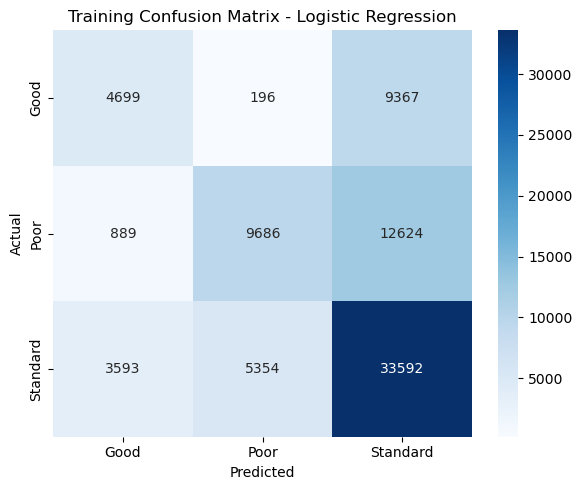


📊 Training Confusion Matrix - Decision Tree


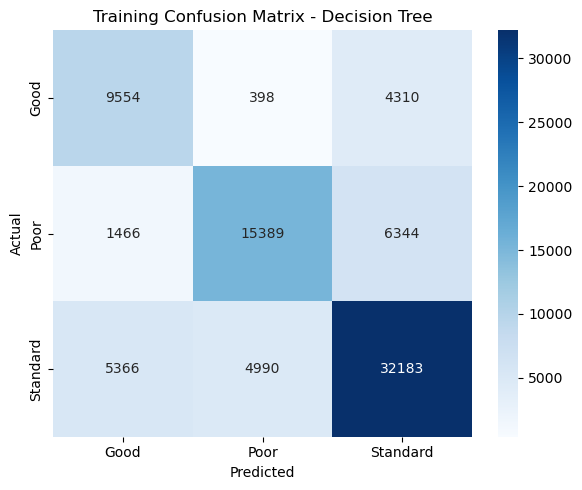


📊 Training Confusion Matrix - KNN


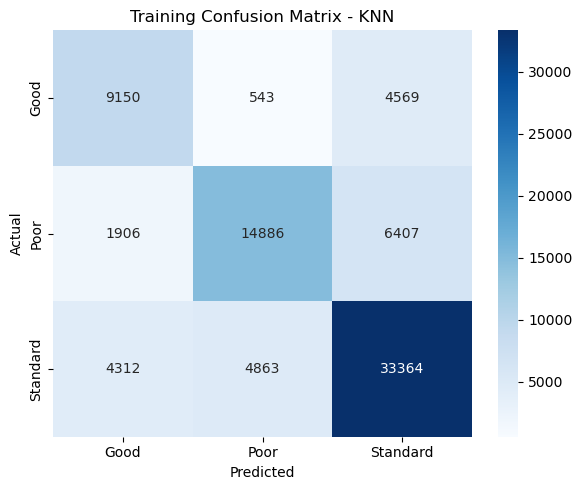


📊 Training Confusion Matrix - Naive Bayes


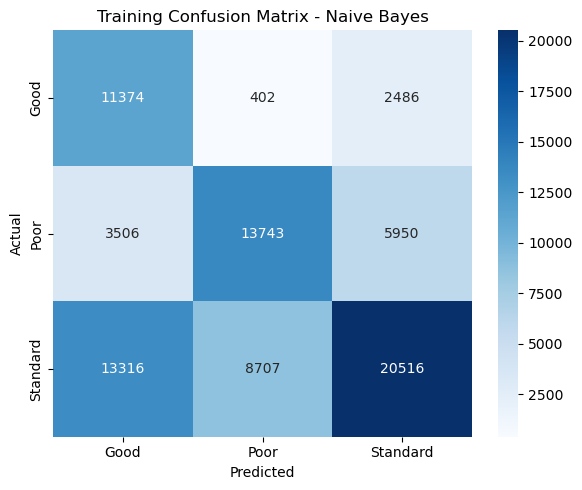


📊 Training Confusion Matrix - Random Forest


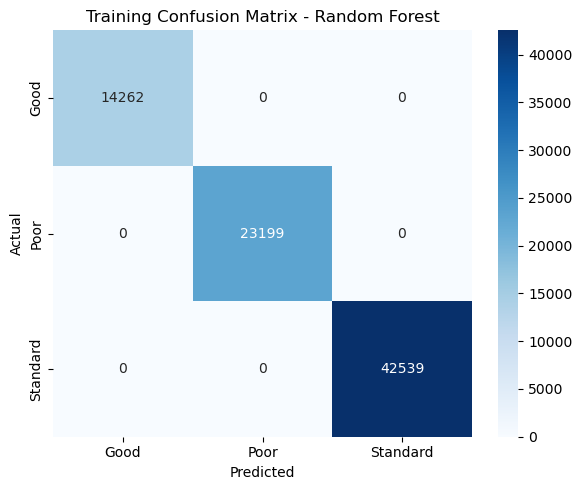

In [16]:
class_labels = sorted(y_train.unique())

for name, model in trained_models.items():
    
    print(f"\n📊 Training Confusion Matrix - {name}")
    
    # Predictions on TRAIN DATA
    y_train_pred = model.predict(X_train_scaled)
    
    cm = confusion_matrix(
        y_train,
        y_train_pred,
        labels=class_labels
    )
    
    # Plot
    plt.figure(figsize=(6, 5))
    
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_labels,
        yticklabels=class_labels
    )
    
    plt.title(f"Training Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    
    plt.tight_layout()
    plt.show()